# MWD Formation Pressure Testing — Well 15/9-F-1, Run 4

This notebook covers the TesTrak MWD (Measurement-While-Drilling) formation pressure test
data for Volve well **15/9-F-1**, Run 4. It's split into two parts that build on each other:

1. **Raw signal exploration** — download the raw `.LAS` files straight from the Databricks
   Volume and look at what the tool actually recorded (pressure, volume, and modulo-pressure
   traces) for every test station.
2. **Formation Rate Analysis (FRA)** — re-derive the actual formation pressure from those raw
   traces using the same physical method Baker Hughes' TesTrak tool uses internally, then check
   the result against Baker Hughes' own officially reported numbers (transcribed from the
   `FM_PRESS_RAW_RUN4_MWD_REPORT_1.PDF` run summary). This turns the raw plots into a real
   accuracy check against a commercial downhole tool, not just a visualization exercise.

**Why FRA:** Think of it like calculating resting blood pressure from exercise data. Because pressure varies with the formation flow rate (Qf), FRA plots pressure against flow rate and extrapolates the trend to zero flow (Qf = 0) to determine the true "resting" formation pressure directly from raw data.


## 1. Install and Import Dependencies

In [ ]:
!pip install -q databricks-sdk lasio
!pip install -Uq plotly
!pip install -q tabula-py pdfplumber

# --- Static export toggle (read before running) -----------------------------------------
# This notebook defaults to Plotly's interactive renderer, which is the nicest experience
# while you're editing in Colab -- you can zoom, hover for values, etc.
# GitHub's notebook preview, however, only displays static images: it cannot render
# interactive Plotly widgets. So right before you push this notebook to GitHub:
#   1. Uncomment the two lines below (kaleido install + import)
#   2. Comment out the "colab" renderer line further down and uncomment the "png" one
#   3. Restart the runtime and re-run all cells so every figure gets baked in as a PNG

# Comment these 2 lines to run interactive plots
!pip install -Uq kaleido==0.2.1
import kaleido

import os
import numpy as np
import lasio
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from databricks.sdk import WorkspaceClient
from google.colab import userdata
from IPython.display import display, Markdown

# Renderers:
# pio.renderers.default = "colab" # <-- uncomment (and comment the line below) to for interactive plots
pio.renderers.default = "png"

## 2. Configuration and Authentication

In [ ]:
databricks_host = userdata.get('DATABRICKS_HOST')
databricks_token = userdata.get('DATABRICKS_TOKEN')

os.environ["DATABRICKS_HOST"] = databricks_host
os.environ["DATABRICKS_TOKEN"] = databricks_token

w = WorkspaceClient()

# Constants
LOCAL_DATA_DIR = "/content/wells_data"
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

WELL_PATH = "/Volumes/equinor_asa_volve_data_village/public/volve/Well_logs/03.PRESSURE/15_9-F-1"
PREFIX = "FM_PRESS_RAW_RUN4_MWD_"
SUFFIX = ".LAS"
N_FILES_FALLBACK = 13  # the PDF run summary reports 13 test stations for RUN 4

# Visualization settings
WELL_NAME = "15/9-F-1"
PALETTE = px.colors.qualitative.Bold

## 3. Ground Truth: Baker Hughes' Officially Reported Results

Station numbering runs from deepest (Station 1, 3977.0 m MD) to shallowest (Station 13, 3273.1 m
MD), since the tool was pulled up-hole between tests.


In [ ]:
import logging
import pdfplumber
import tabula

logging.getLogger("tabula.backend").setLevel(logging.ERROR)

REPORT_FILENAME = "FM_PRESS_RAW_RUN4_MWD_REPORT_1.PDF"
local_report_path = os.path.join(LOCAL_DATA_DIR, REPORT_FILENAME)

# Download the run summary PDF from the same Volume directory as the LAS files.
try:
    remote_report_path = f"{WELL_PATH}/{REPORT_FILENAME}"
    response = w.files.download(remote_report_path)
    with open(local_report_path, "wb") as f:
        f.write(response.contents.read())
    print(f"Downloaded run summary PDF: {remote_report_path}")
except Exception as e:
    print(f"Could not download the report PDF from the Volume ({e}).")
    print("If it lives elsewhere, upload it manually in Colab (folder icon on the left, or "
          "`from google.colab import files; files.upload()`) and point `local_report_path` at it.")
    raise


def find_page_with_keyword(pdf_path, keyword):
    """Scans the text layer of every page and returns the 1-indexed page number of the
    first match -- validating the target page instead of assuming it."""
    with pdfplumber.open(pdf_path) as pdf:
        for i, page in enumerate(pdf.pages, start=1):
            text = page.extract_text() or ""
            if keyword.upper() in text.upper():
                return i
    return None


condensed_page = find_page_with_keyword(local_report_path, "CONDENSED")
if condensed_page is None:
    raise RuntimeError("Could not locate the 'TesTrak Data CONDENSED' table in the PDF -- "
                        "check the report format (page layout may differ between runs/wells).")
print(f"Found the 'CONDENSED' data table on PDF page {condensed_page}")

tables = tabula.read_pdf(local_report_path, pages=str(condensed_page), multiple_tables=True)
if not tables:
    raise RuntimeError(f"tabula found no tables on page {condensed_page}.")

raw_table = tables[0]
# Clean column names: strip newlines/carriage returns and bracketed units, e.g. "FPres1\r[bara]" -> "FPres1"
raw_table.columns = [c.replace('\r', ' ').replace('\n', ' ').split('[')[0].strip() for c in raw_table.columns]
print("Extracted raw columns:", raw_table.columns.tolist())
raw_table

Downloaded run summary PDF: /Volumes/equinor_asa_volve_data_village/public/volve/Well_logs/03.PRESSURE/15_9-F-1/FM_PRESS_RAW_RUN4_MWD_REPORT_1.PDF
Found the 'CONDENSED' data table on PDF page 5
Extracted raw columns: ['Station #', 'Date DD.MM.YY', 'Time HH:MM:SS', 'MD', 'TVD', 'APresA', 'FPres1', 'FPres2', 'FPres3', 'Mob1', 'Mob2', 'Mob3']


,Station #,Date DD.MM.YY,Time HH:MM:SS,MD,TVD,APresA,FPres1,FPres2,FPres3,Mob1,Mob2,Mob3
0,1,18.08.13,21:42:06,3462.6,3172.2,426.7,353.5,353.5,353.5,8.2,7.8,7.8
1,2,18.08.13,22:20:48,3451.9,3162.2,425.0,351.3,351.3,351.3,6.2,5.4,5.3
2,3,18.08.13,23:03:51,3360.8,3080.0,413.2,342.0,342.2,342.2,0.7,0.7,0.6
3,4,18.08.13,23:37:52,3337.2,3060.0,411.3,368.6,na,na,0.1,na,na
4,5,19.08.13,00:10:18,3332.4,3056.0,410.1,340.6,340.6,340.6,149.2,221.1,217.5
5,6,19.08.13,00:33:41,3320.8,3046.3,412.1,345.4,na,na,3.9,na,na


In [ ]:
#@title Baker Hughes TesTrak® Data CONDENSED Pressure table (Pg. 5)
COLUMN_MAP = {
    "Station #": "station",
    "MD": "md_m",
    "TVD": "tvd_m",
    "APresA": "apresa_bara",
    "FPres1": "fpres1_bara",
    "FPres2": "fpres2_bara",
    "FPres3": "fpres3_bara",
    "Mob1": "mob1",
    "Mob2": "mob2",
    "Mob3": "mob3",
}
missing = [c for c in COLUMN_MAP if c not in raw_table.columns]
if missing:
    raise RuntimeError(f"Expected column(s) not found in extracted table: {missing}. "
                        f"Got: {raw_table.columns.tolist()}")

REPORTED_STATIONS = raw_table[list(COLUMN_MAP)].rename(columns=COLUMN_MAP).copy()
for col in REPORTED_STATIONS.columns:
    REPORTED_STATIONS[col] = pd.to_numeric(REPORTED_STATIONS[col], errors="coerce")

REPORTED_STATIONS = REPORTED_STATIONS.dropna(subset=["station", "fpres3_bara"]).copy()
REPORTED_STATIONS["station"] = REPORTED_STATIONS["station"].astype(int)
REPORTED_STATIONS = REPORTED_STATIONS.sort_values("station").reset_index(drop=True)

# FPres3 is the last (most-repeated, most-stable) buildup pressure of the "Optimized Test" --
# treat it as the vendor's best estimate per station for comparison purposes.
REPORTED_STATIONS["fpres_best_bara"] = REPORTED_STATIONS["fpres3_bara"]

print(f"Parsed {len(REPORTED_STATIONS)} stations from the PDF's CONDENSED table.")
REPORTED_STATIONS

Parsed 4 stations from the PDF's CONDENSED table.


,station,md_m,tvd_m,apresa_bara,fpres1_bara,fpres2_bara,fpres3_bara,mob1,mob2,mob3,fpres_best_bara
0,1,3462.6,3172.2,426.7,353.5,353.5,353.5,8.2,7.8,7.8,353.5
1,2,3451.9,3162.2,425.0,351.3,351.3,351.3,6.2,5.4,5.3,351.3
2,3,3360.8,3080.0,413.2,342.0,342.2,342.2,0.7,0.7,0.6,342.2
3,5,3332.4,3056.0,410.1,340.6,340.6,340.6,149.2,221.1,217.5,340.6


## 4. Discover & Download Available LAS Files

Rather than assuming a fixed file count, this lists whatever `.LAS` files actually exist in the
Volume and downloads all of them -- falling back to the PDF's reported station count (13) only
if the directory listing isn't available.


In [ ]:
try:
    remote_files = [f.path for f in w.files.list_directory_contents(WELL_PATH)
                    if f.path.endswith(SUFFIX) and PREFIX in f.path]
    remote_files.sort()
    print(f"Found {len(remote_files)} LAS files in the Volume.")
except Exception as e:
    print(f"Directory listing failed ({e}); falling back to N={N_FILES_FALLBACK} sequential files.")
    remote_files = [f"{WELL_PATH}/{PREFIX}{i}{SUFFIX}" for i in range(1, N_FILES_FALLBACK + 1)]

local_paths = {}
for remote_path in remote_files:
    fname = os.path.basename(remote_path)
    local_path = os.path.join(LOCAL_DATA_DIR, fname)
    response = w.files.download(remote_path)
    with open(local_path, "wb") as f:
        f.write(response.contents.read())
    local_paths[fname] = local_path
    print(f"Downloaded: {fname}")

Found 6 LAS files in the Volume.
Downloaded: FM_PRESS_RAW_RUN4_MWD_1.LAS
Downloaded: FM_PRESS_RAW_RUN4_MWD_2.LAS
Downloaded: FM_PRESS_RAW_RUN4_MWD_3.LAS
Downloaded: FM_PRESS_RAW_RUN4_MWD_4.LAS
Downloaded: FM_PRESS_RAW_RUN4_MWD_5.LAS
Downloaded: FM_PRESS_RAW_RUN4_MWD_6.LAS


## 5. Parse LAS Files

Each file corresponds to one test station (Baker Hughes runs the tool up-hole between stations,
so **file order = station order**: the first file is Station 1, the second is Station 2, etc.).
Where a header parameter resembling MD/depth exists in the LAS file itself, it's extracted too,
purely as a sanity check against that file-order assumption -- printed below so the mapping can
be visually confirmed rather than taken on faith.


In [ ]:
def extract_header_md(las_obj):
    # Best-effort scan of LAS header/params for a depth-like mnemonic. Returns None if absent.
    candidates = ["MD", "DEPT", "DEPTH", "STRT"]
    for section in (las_obj.well, las_obj.params):
        for item in section:
            if item.mnemonic.upper() in candidates:
                try:
                    return float(item.value)
                except (TypeError, ValueError):
                    continue
    return None

all_dfs = []
station_lookup = []  # (station_number, header_md, filename)

for i, (fname, local_path) in enumerate(sorted(local_paths.items()), start=1):
    las_data = lasio.read(local_path)
    temp_df = las_data.df().reset_index()
    temp_df['source_file'] = fname
    temp_df['station'] = i
    all_dfs.append(temp_df)

    header_md = extract_header_md(las_data)
    station_lookup.append((i, header_md, fname))
    md_note = f"{header_md:.1f} m" if header_md is not None else "not present in header"
    print(f"Station {i:>2} <- {fname}  (header MD: {md_note})")

combined_df = pd.concat(all_dfs, ignore_index=True)
N_STATIONS = combined_df['station'].nunique()
print(f"\nCombined dataset shape: {combined_df.shape}  ({N_STATIONS} stations)")
combined_df.head()

Station  1 <- FM_PRESS_RAW_RUN4_MWD_1.LAS  (header MD: 2.1 m)
Station  2 <- FM_PRESS_RAW_RUN4_MWD_2.LAS  (header MD: 2.1 m)
Station  3 <- FM_PRESS_RAW_RUN4_MWD_3.LAS  (header MD: 2.1 m)
Station  4 <- FM_PRESS_RAW_RUN4_MWD_4.LAS  (header MD: 2.1 m)
Station  5 <- FM_PRESS_RAW_RUN4_MWD_5.LAS  (header MD: 2.1 m)
Station  6 <- FM_PRESS_RAW_RUN4_MWD_6.LAS  (header MD: 2.1 m)

Combined dataset shape: (28217, 13)  (6 stations)


,TIME,DD_PRESS,DD_VOLUME,TEMP,DD_PRESS_MOD_1000,DD_PRESS_MOD_100,DD_PRESS_MOD_10,DD_PRESS_MOD_1,DD_PRESS_MOD_01,DD_PRESS_MOD_001,DD_PRESS_MOD_0001,source_file,station
0,2.1,426.60112,0.0,82.563,426.601,26.6011,6.60112,0.601115,0.001115,0.001115,0.000115,FM_PRESS_RAW_RUN4_MWD_1.LAS,1
1,2.2,426.62186,0.0,82.563,426.622,26.6219,6.62186,0.621863,0.021863,0.001863,0.000863,FM_PRESS_RAW_RUN4_MWD_1.LAS,1
2,2.3,426.58421,0.0,82.563,426.584,26.5842,6.58421,0.584213,0.084213,0.004213,0.000213,FM_PRESS_RAW_RUN4_MWD_1.LAS,1
3,2.4,426.59721,0.0,82.563,426.597,26.5972,6.59721,0.597208,0.097208,0.007208,0.000208,FM_PRESS_RAW_RUN4_MWD_1.LAS,1
4,2.5,426.65119,0.0,82.563,426.651,26.6512,6.65119,0.651192,0.051192,0.001192,0.000192,FM_PRESS_RAW_RUN4_MWD_1.LAS,1


## 6. Raw Signal Exploration

Before doing any analysis, it's worth just looking at what the tool recorded. Each row below is
one test station; each column shows a different raw channel against time:

- **Volume vs Time** -- the pump piston position as it draws fluid out of the formation
  (drawdown) and pushes it back (buildup).
- **Raw Pressure vs Time** -- the direct quartz gauge reading; you can see the characteristic
  drawdown dip followed by a buildup recovery, repeated up to three times per station.
- **Mod Pressure vs Time** -- a "zoomed-in" modulo/residual pressure signal used to QC how well
  each buildup has actually stabilized (a flat trace here means a clean, trustworthy reading).

This is the same multi-variable grid from the original exploratory notebook, now driven by
however many stations were actually discovered in Section 4 (rather than a hardcoded count).


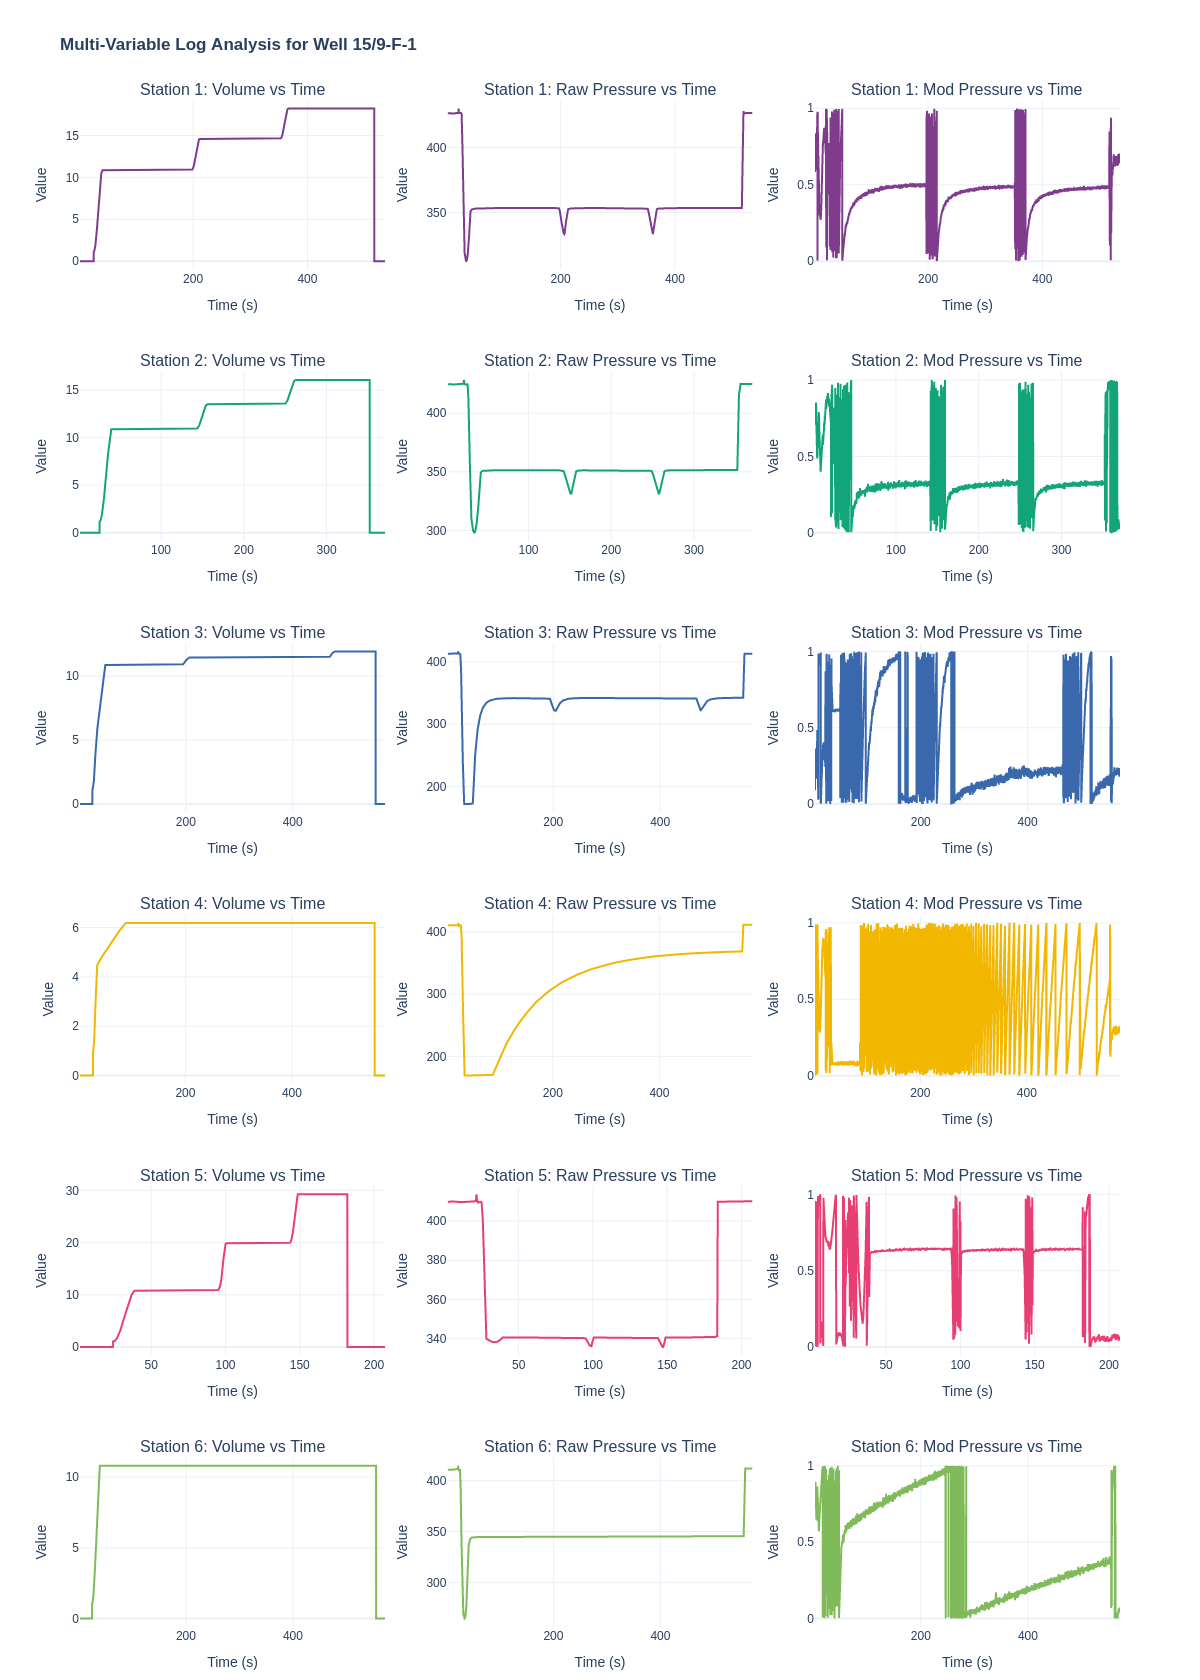

In [ ]:
variables = ['DD_VOLUME', 'DD_PRESS', 'DD_PRESS_MOD_1']
column_titles = ['Volume vs Time', 'Raw Pressure vs Time', 'Mod Pressure vs Time']
stations = sorted(combined_df['station'].unique())

fig_bulk = make_subplots(
    rows=len(stations),
    cols=3,
    subplot_titles=[f"Station {s}: {title}" for s in stations for title in column_titles],
    vertical_spacing=0.4 / len(stations),
    horizontal_spacing=0.06,
)

for row, station in enumerate(stations, start=1):
    df_subset = combined_df[combined_df['station'] == station]
    run_color = PALETTE[(station - 1) % len(PALETTE)]

    for col, var in enumerate(variables, start=1):
        fig_bulk.add_trace(
            go.Scatter(
                x=df_subset['TIME'],
                y=df_subset[var],
                name=f"Station {station} - {var}",
                line=dict(color=run_color),
                showlegend=False,
            ),
            row=row, col=col,
        )

fig_bulk.update_layout(
    height=280 * len(stations),
    width=1200,
    title_text=f"<b>Multi-Variable Log Analysis for Well {WELL_NAME}</b>",
    template='plotly_white',
    margin=dict(t=100, b=50),
)

fig_bulk.update_xaxes(title_text="Time (s)")
fig_bulk.update_yaxes(title_text="Value")

fig_bulk.show()

## 7. Auto-Detecting Stabilized Test Pressures

Baker Hughes' own "History plot" marks each buildup with a small
magenta dot once the pressure has stabilized, and a red dot at the very end once the pad
retracts and the sensor reads the annulus (mud) pressure again. Those aren't manually placed --
they're just the pressure at the end of each *flat stretch* in the volume trace. This section
detects those flat stretches directly from the raw data, with no proprietary algorithm and no
need for the PDF:

- The green **volume** trace moves in a "ramp, then hold" pattern: a **ramp** is one pump stroke
  (drawdown), a **hold** is the pressure recovering afterward (buildup).
- The very first hold, *before* any ramp has happened, is just the static mud pressure while the
  pad is being set -- that one gets skipped.
- Every hold *after* the first ramp is a genuine buildup. The pressure at the tail end of each
  such hold (right before the next ramp starts) is the stabilized reading -- the magenta dot.
- The last recorded pressure sample, after the tool has finished all repeat tests and the pad
  pulls away, is the annulus pressure -- the red dot.


In [ ]:
def find_stabilized_pressures(df, volume_col='DD_VOLUME', pressure_col='DD_PRESS', time_col='TIME',
                               ramp_thresh_frac=0.1, min_plateau_seconds=3.0, max_tests=3, smooth_window=5):

    d = df.sort_values(time_col).reset_index(drop=True)

    # Light smoothing on volume so sensor noise doesn't create spurious ramp/hold flips
    vol_smooth = d[volume_col].rolling(smooth_window, min_periods=1, center=True).median()
    dt = d[time_col].diff()
    rate = (vol_smooth.diff() / dt).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    max_rate = rate.abs().max()
    ramp_thresh = ramp_thresh_frac * max_rate if max_rate > 0 else 0.0
    is_ramp = rate.abs() > ramp_thresh

    # Collapse into contiguous ramp / hold segments: (start_idx, end_idx, is_ramp)
    segments = []
    start = 0
    for i in range(1, len(is_ramp) + 1):
        if i == len(is_ramp) or bool(is_ramp.iloc[i]) != bool(is_ramp.iloc[start]):
            segments.append((start, i - 1, bool(is_ramp.iloc[start])))
            start = i

    # Only start counting "holds" as buildups once the first ramp has occurred -- this skips
    # the pre-test static baseline, which is technically a hold too but isn't a real buildup.
    seen_ramp = False
    stabilized = []
    for seg_start, seg_end, ramp in segments:
        if ramp:
            seen_ramp = True
            continue
        if not seen_ramp:
            continue
        duration = d[time_col].iloc[seg_end] - d[time_col].iloc[seg_start]
        if duration < min_plateau_seconds:
            continue
        stabilized.append({'time': d[time_col].iloc[seg_end], 'pressure': d[pressure_col].iloc[seg_end]})
        if len(stabilized) >= max_tests:
            break

    for i, s in enumerate(stabilized, start=1):
        s['test'] = i

    apresa = {'time': d[time_col].iloc[-1], 'pressure': d[pressure_col].iloc[-1]}
    return stabilized, apresa


# Run detection for every station
station_stabilization = {}
for station in stations:
    d_station = combined_df[combined_df['station'] == station]
    stabilized, apresa = find_stabilized_pressures(d_station)
    station_stabilization[station] = {'tests': stabilized, 'apresa': apresa}
    test_summary = ", ".join(f"Test{s['test']}={s['pressure']:.3f}" for s in stabilized)
    print(f"Station {station:>2}: {test_summary}  |  APresA={apresa['pressure']:.2f}")

Station  1: Test1=426.675  |  APresA=426.67
Station  2: Test1=425.047  |  APresA=425.05
Station  3: Test1=413.224  |  APresA=413.22
Station  4: Test1=368.624, Test2=411.296  |  APresA=411.30
Station  5: Test1=410.065  |  APresA=410.07
Station  6: Test1=345.399, Test2=412.057  |  APresA=412.06


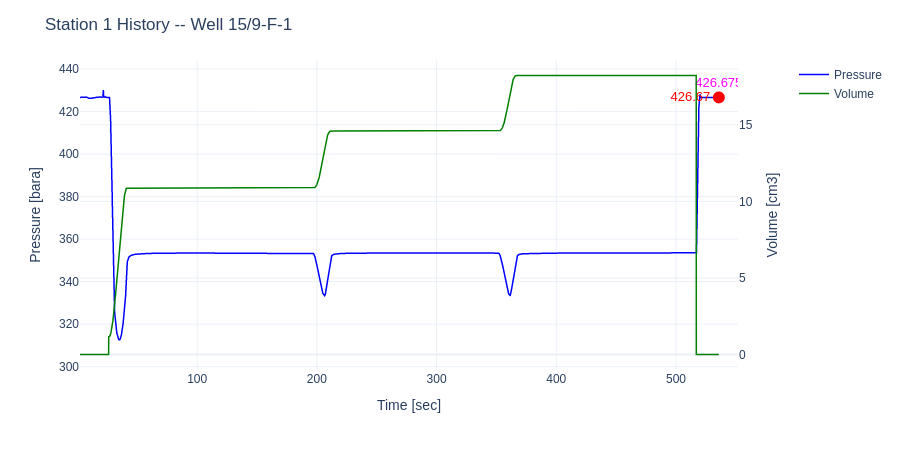

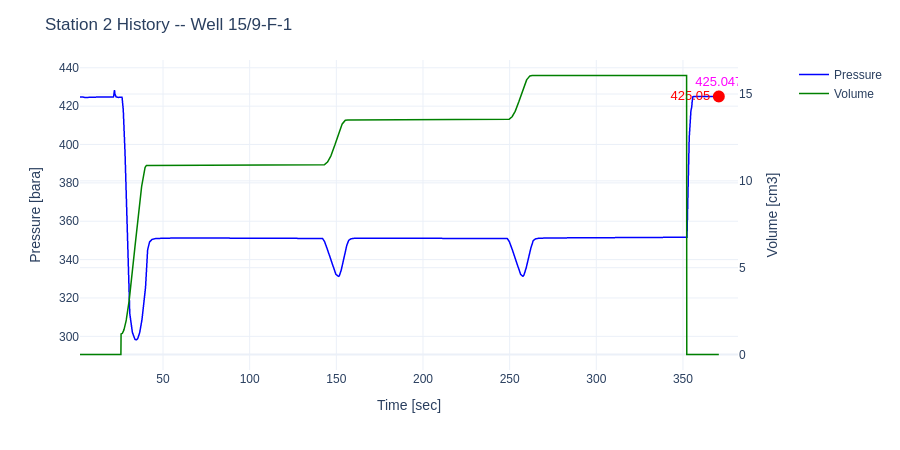

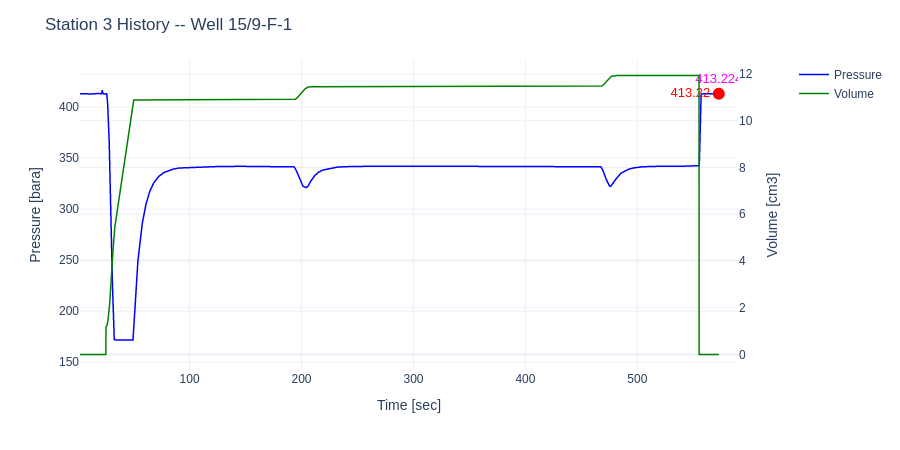

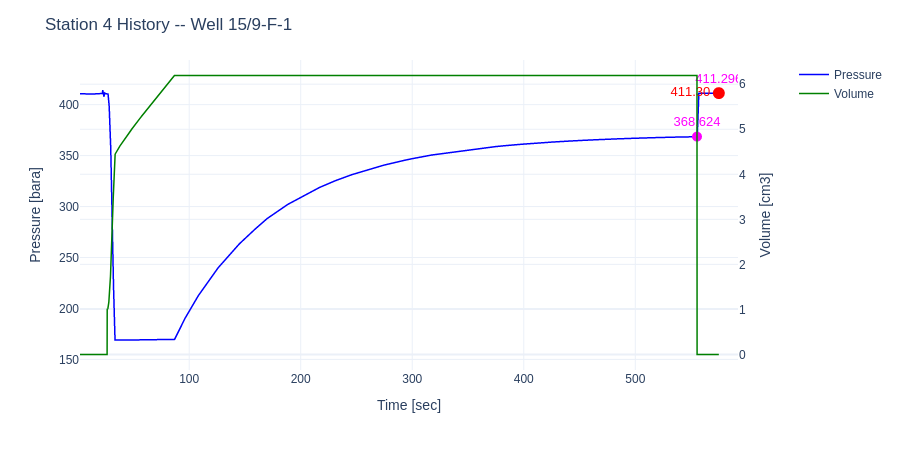

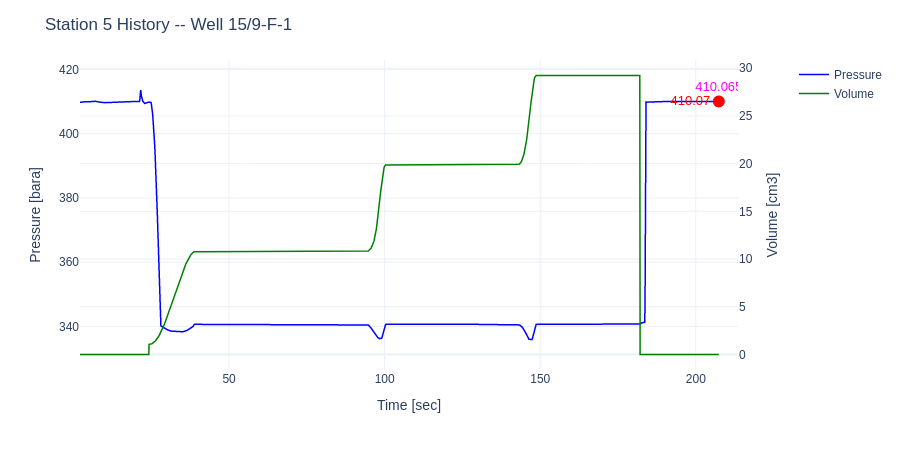

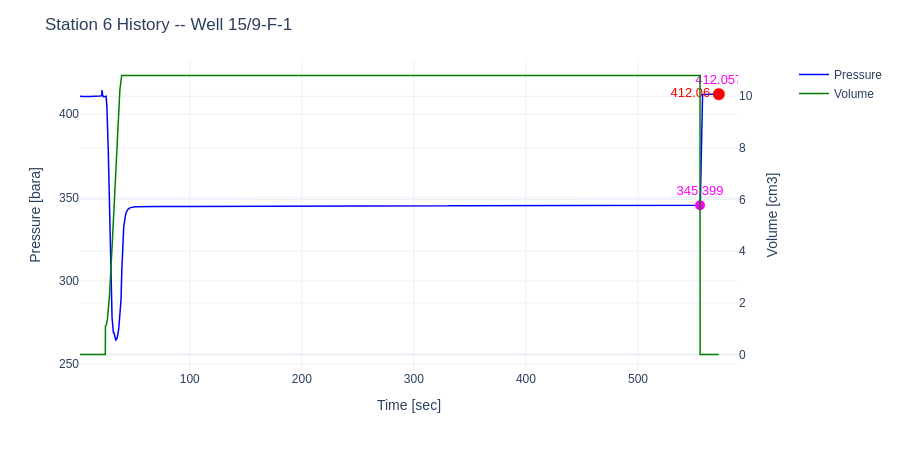

In [ ]:
# Annotated per-station history plots -- one full-size dual-axis chart per station, styled to
# match Baker Hughes' own History plot layout: pressure (blue) + volume (green) on twin y-axes,
# magenta dots for each stabilized buildup, a red dot for the final annulus pressure, with
# color-matched value labels next to each point.

for station in stations:
    d = combined_df[combined_df['station'] == station].sort_values('TIME')
    info = station_stabilization[station]

    fig_station = make_subplots(specs=[[{"secondary_y": True}]])

    fig_station.add_trace(
        go.Scatter(x=d['TIME'], y=d['DD_PRESS'], mode='lines', line=dict(color='blue', width=1.5),
                   name='Pressure'),
        secondary_y=False,
    )
    fig_station.add_trace(
        go.Scatter(x=d['TIME'], y=d['DD_VOLUME'], mode='lines', line=dict(color='green', width=1.5),
                   name='Volume'),
        secondary_y=True,
    )

    for s in info['tests']:
        fig_station.add_trace(
            go.Scatter(x=[s['time']], y=[s['pressure']], mode='markers+text',
                       marker=dict(color='magenta', size=10),
                       text=[f"{s['pressure']:.3f}"], textposition='top center',
                       textfont=dict(color='magenta', size=13), showlegend=False),
            secondary_y=False,
        )

    apresa = info['apresa']
    fig_station.add_trace(
        go.Scatter(x=[apresa['time']], y=[apresa['pressure']], mode='markers+text',
                   marker=dict(color='red', size=12),
                   text=[f"{apresa['pressure']:.2f}"], textposition='middle left',
                   textfont=dict(color='red', size=13), showlegend=False),
        secondary_y=False,
    )

    # Headroom above the highest pressure so the annulus-pressure marker/label aren't flush
    # against the top border, plus a little breathing room on the right for the last point.
    p_min, p_max = d['DD_PRESS'].min(), d['DD_PRESS'].max()
    p_pad = 0.12 * (p_max - p_min if p_max > p_min else 1.0)
    t_pad = 0.03 * (d['TIME'].max() - d['TIME'].min())

    fig_station.update_layout(
        width=900, height=450, template='plotly_white',
        title_text=f"Station {station} History -- Well {WELL_NAME}",
        margin=dict(t=60, r=40),
    )
    fig_station.update_xaxes(title_text="Time [sec]", range=[d['TIME'].min(), d['TIME'].max() + t_pad])
    fig_station.update_yaxes(title_text="Pressure [bara]", range=[p_min - p_pad, p_max + p_pad], secondary_y=False)
    fig_station.update_yaxes(title_text="Volume [cm3]", secondary_y=True)
    fig_station.show()


**Sanity check against the vendor's report:** the last detected test (`Test 3`, the most
repeated and most stable) and the detected `APresA` can be compared directly to the PDF's
`FPres3` and `APresA` columns -- this validates the plateau-detection logic itself, independent
of the FRA regression done in the next section.


In [ ]:
auto_rows = []
for station in stations:
    info = station_stabilization[station]
    test3 = next((s['pressure'] for s in info['tests'] if s['test'] == 3), np.nan)
    auto_rows.append({
        'station': station,
        'auto_test3_bara': test3,
        'auto_apresa_bara': info['apresa']['pressure'],
    })

auto_detect_df = pd.DataFrame(auto_rows).merge(
    REPORTED_STATIONS[['station', 'fpres3_bara', 'apresa_bara']], on='station', how='left'
)
auto_detect_df['test3_error_bara'] = (auto_detect_df['auto_test3_bara'] - auto_detect_df['fpres3_bara']).abs()
auto_detect_df['apresa_error_bara'] = (auto_detect_df['auto_apresa_bara'] - auto_detect_df['apresa_bara']).abs()

print(f"Mean abs error (Test 3 plateau vs. reported FPres3): {auto_detect_df['test3_error_bara'].mean():.3f} bara")
print(f"Mean abs error (detected APresA vs. reported APresA): {auto_detect_df['apresa_error_bara'].mean():.3f} bara")
auto_detect_df.round(3)

Mean abs error (Test 3 plateau vs. reported FPres3): nan bara
Mean abs error (detected APresA vs. reported APresA): 0.033 bara


,station,auto_test3_bara,auto_apresa_bara,fpres3_bara,apresa_bara,test3_error_bara,apresa_error_bara
0,1,NaN,426.675,353.5,426.7,NaN,0.025
1,2,NaN,425.047,351.3,425.0,NaN,0.047
2,3,NaN,413.224,342.2,413.2,NaN,0.024
3,4,NaN,411.296,NaN,NaN,NaN,NaN
4,5,NaN,410.065,340.6,410.1,NaN,0.035
5,6,NaN,412.057,NaN,NaN,NaN,NaN


## 8. Re-derive Formation Pressure via Formation Rate Analysis (FRA)

For each station: compute the instantaneous flow rate `Qf = d(DD_VOLUME)/d(TIME)`, then fit a straight line through Pressure vs. Qf. The y-intercept (Qf -> 0) is the extrapolated formation pressure. the same quantity the vendor's proprietary FRA algorithm reports.

Note: this analysis runs across each station's **full recorded history** (all repeat tests combined), so it corresponds most closely to the vendor's final/most-stable buildup value (`FPres3` / `fpres_best_bara`), not to each individual repeat cycle separately.

**A raw-data worth flagging:** `Qf` is a numerical derivative (`dV/dt`), and a derivative is only as good as its denominator. A single near-duplicate timestamp (`dt` very close to zero) turns an ordinary, physically-reasonable `dV` into a huge, meaningless `Qf` spike -- one bad
sample computed above showed a **393 cm3/sec** spike against a true range of about 1 cm3/sec.
Left in, that one point forces every plot's axis out to include it, squashing the real, physically-meaningful data into a sliver in the corner. `compute_qf()` below filters those out before anything gets fit or plotted, so the same clean signal drives both.


In [ ]:
def compute_qf(df, min_dt_frac=0.2, outlier_pct=1.0):
    d = df.sort_values('TIME').reset_index(drop=True)
    dt = d['TIME'].diff()
    qf = d['DD_VOLUME'].diff() / dt

    positive_dt = dt[dt > 0]
    median_dt = positive_dt.median() if len(positive_dt) else np.nan
    dt_ok = dt > (median_dt * min_dt_frac) if pd.notna(median_dt) else dt.notna()

    valid = qf.replace([np.inf, -np.inf], np.nan).notna() & d['DD_PRESS'].notna() & dt_ok

    if valid.sum() > 10:
        lo, hi = np.percentile(qf[valid], [outlier_pct, 100 - outlier_pct])
        valid &= qf.between(lo, hi)

    return qf, d['DD_PRESS'], valid


def fra_regression(df):
    qf, press, valid = compute_qf(df)

    x = qf[valid].values
    y = press[valid].values
    if len(x) < 5:
        return np.nan, np.nan, np.nan

    slope, intercept = np.polyfit(x, y, 1)
    y_hat = slope * x + intercept
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return slope, intercept, r2


results = []
for station, df_station in combined_df.groupby('station'):
    slope, intercept, r2 = fra_regression(df_station)
    results.append({
        "station": station,
        "fpres_computed_bara": intercept,
        "fra_slope": slope,
        "r_squared": r2,
    })

results_df = pd.DataFrame(results)

# Join against the vendor's officially reported values
comparison_df = results_df.merge(REPORTED_STATIONS, on="station", how="left")
comparison_df["abs_error_bara"] = (comparison_df["fpres_computed_bara"] - comparison_df["fpres_best_bara"]).abs()
comparison_df["pct_error"] = 100 * comparison_df["abs_error_bara"] / comparison_df["fpres_best_bara"]

comparison_df[["station", "fpres_computed_bara", "fpres_best_bara", "abs_error_bara", "pct_error", "r_squared"]].round(3)

,station,fpres_computed_bara,fpres_best_bara,abs_error_bara,pct_error,r_squared
0,1,359.607,353.5,6.107,1.728,0.044
1,2,360.243,351.3,8.943,2.546,0.087
2,3,344.878,342.2,2.678,0.783,0.550
3,4,335.137,NaN,NaN,NaN,0.446
4,5,358.297,340.6,17.697,5.196,0.028
5,6,349.641,NaN,NaN,NaN,0.058


## 9. Validation Dashboard

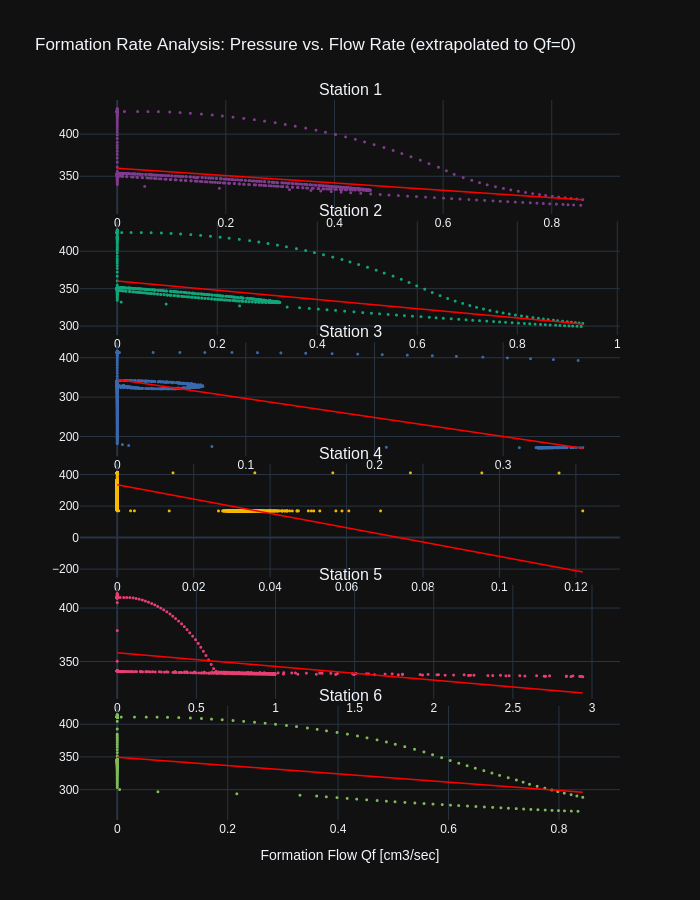

In [ ]:
#@title Test A. FRA regression small multiples: Pressure vs. Formation Flow Rate, one panel per station ---
fig_fra = make_subplots(rows=len(stations), cols=1, subplot_titles=[f"Station {s}" for s in stations],
                         vertical_spacing=0.01)

for row, station in enumerate(stations, start=1):
    d = combined_df[combined_df['station'] == station]
    qf, press, valid = compute_qf(d)

    color = PALETTE[(station - 1) % len(PALETTE)]
    fig_fra.add_trace(go.Scatter(x=qf[valid], y=press[valid], mode='markers',
                                  marker=dict(size=3, color=color), showlegend=False), row=row, col=1)

    row_fit = comparison_df[comparison_df['station'] == station]
    if not row_fit.empty and pd.notna(row_fit['fra_slope'].values[0]) and valid.sum() > 0:
        slope = row_fit['fra_slope'].values[0]
        intercept = row_fit['fpres_computed_bara'].values[0]
        x_line = np.linspace(0, qf[valid].max(), 20)
        fig_fra.add_trace(go.Scatter(x=x_line, y=slope * x_line + intercept, mode='lines',
                                      line=dict(color='red', width=1.5), showlegend=False), row=row, col=1)

        # Explicit, padded axis range from the *filtered* data -- keeps a single station's
        # residual noise from stretching every panel's scale.
        x_min, x_max = min(0.0, float(qf[valid].min())), float(qf[valid].max())
        pad = 0.08 * (x_max - x_min if x_max > x_min else 1.0)
        fig_fra.update_xaxes(range=[x_min - pad, x_max + pad], row=row, col=1)

fig_fra.update_layout(height=150 * len(stations), template="plotly_dark",
                       title="Formation Rate Analysis: Pressure vs. Flow Rate (extrapolated to Qf=0)")
fig_fra.update_xaxes(title_text="Formation Flow Qf [cm3/sec]", row=len(stations), col=1)
fig_fra.show()

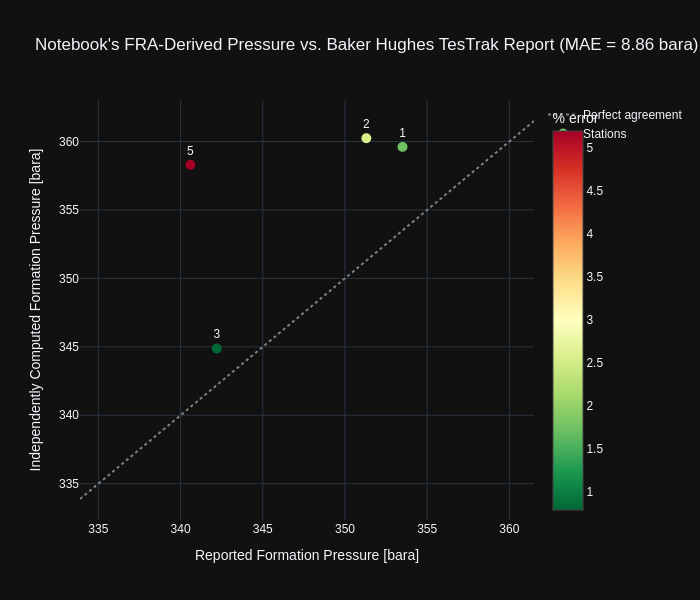

In [ ]:
#@title Test B. Validation parity plot: our extrapolated pressure vs. Baker Hughes' reported value ---
fig_parity = go.Figure()

lo = min(comparison_df['fpres_computed_bara'].min(), comparison_df['fpres_best_bara'].min())
hi = max(comparison_df['fpres_computed_bara'].max(), comparison_df['fpres_best_bara'].max())
pad = 0.05 * (hi - lo if hi > lo else 1.0)
lo, hi = lo - pad, hi + pad

fig_parity.add_trace(go.Scatter(x=[lo, hi], y=[lo, hi], mode='lines',
                                 line=dict(color='gray', dash='dot'), name='Perfect agreement'))

fig_parity.add_trace(go.Scatter(
    x=comparison_df['fpres_best_bara'], y=comparison_df['fpres_computed_bara'],
    mode='markers+text', text=comparison_df['station'], textposition='top center',
    marker=dict(size=10, color=comparison_df['pct_error'], colorscale='RdYlGn_r',
                colorbar=dict(title="% error"), showscale=True),
    name='Stations'
))

mae = comparison_df['abs_error_bara'].mean()
fig_parity.update_layout(
    title=f"Notebook's FRA-Derived Pressure vs. Baker Hughes TesTrak Report (MAE = {mae:.2f} bara)",
    xaxis_title="Reported Formation Pressure [bara]",
    yaxis_title="Independently Computed Formation Pressure [bara]",
    template="plotly_dark", height=600,
)
fig_parity.show()

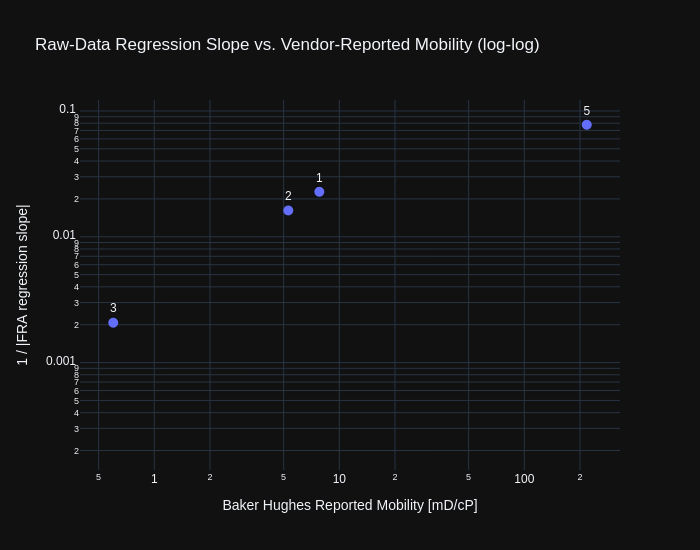

Log-log correlation between reported mobility and 1/slope: r = nan


In [ ]:
#@title Test C. Physics check: does raw regression slope alone track vendor-reported mobility? ---
# Mobility ~ Productivity Index / geometric factor, and PI = Qf / dP = 1 / slope,
# so 1/|slope| should correlate with the vendor's Mob3 even without reproducing their exact
# proprietary constant.
comparison_df['inv_slope'] = 1 / comparison_df['fra_slope'].abs()

fig_corr = px.scatter(
    comparison_df, x='mob3', y='inv_slope', text='station',
    log_x=True, log_y=True,
    labels={'mob3': "Baker Hughes Reported Mobility [mD/cP]", 'inv_slope': "1 / |FRA regression slope|"},
    title="Raw-Data Regression Slope vs. Vendor-Reported Mobility (log-log)",
)
fig_corr.update_traces(textposition='top center', marker=dict(size=10))
fig_corr.update_layout(template="plotly_dark", height=550)
fig_corr.show()

corr = np.corrcoef(np.log(comparison_df['mob3']), np.log(comparison_df['inv_slope']))[0, 1]
print(f"Log-log correlation between reported mobility and 1/slope: r = {corr:.3f}")

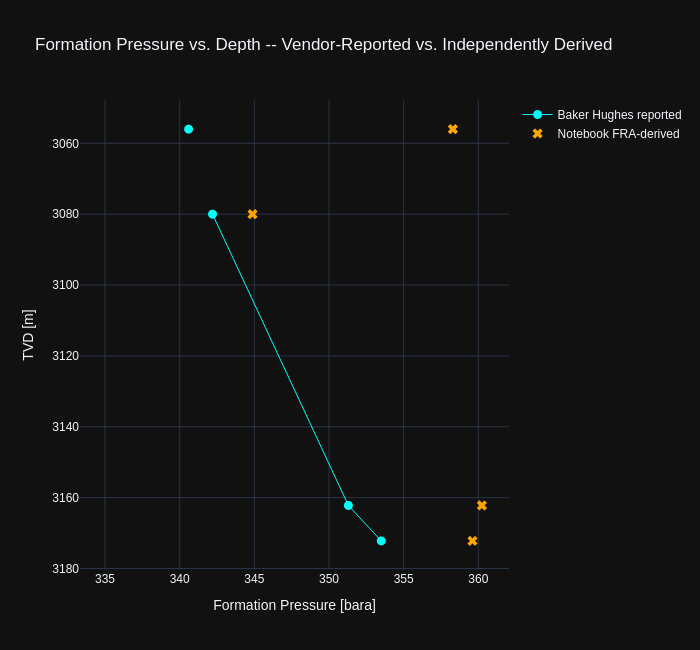

In [ ]:
#@title Test D. Pressure-depth profile: the classic formation-pressure-gradient plot ---
fig_depth = go.Figure()

fig_depth.add_trace(go.Scatter(
    x=comparison_df['fpres_best_bara'], y=comparison_df['tvd_m'], mode='markers+lines',
    name='Baker Hughes reported', marker=dict(size=9, color='cyan'), line=dict(color='cyan', width=1)
))
fig_depth.add_trace(go.Scatter(
    x=comparison_df['fpres_computed_bara'], y=comparison_df['tvd_m'], mode='markers',
    name='Notebook FRA-derived', marker=dict(size=9, symbol='x', color='orange')
))

fig_depth.update_yaxes(autorange='reversed', title='TVD [m]')
fig_depth.update_xaxes(title='Formation Pressure [bara]')
fig_depth.update_layout(
    title="Formation Pressure vs. Depth -- Vendor-Reported vs. Independently Derived",
    template="plotly_dark", height=650,
)
fig_depth.show()

## 10. Summary

In [ ]:
best_station = comparison_df.loc[comparison_df['abs_error_bara'].idxmin()]
worst_station = comparison_df.loc[comparison_df['abs_error_bara'].idxmax()]

report = f"""
### Key figures (computed from this run)

- **{len(comparison_df)} stations** analyzed via from-scratch Formation Rate Analysis (FRA),
  independently re-deriving formation pressure from raw MWD sensor data.
- **Mean absolute error vs. Baker Hughes TesTrak report: {comparison_df['abs_error_bara'].mean():.2f} bara**
  ({comparison_df['pct_error'].mean():.2f}% average deviation).
- **Best match:** Station {int(best_station['station'])}, off by only
  {best_station['abs_error_bara']:.2f} bara ({best_station['pct_error']:.2f}%).
- **Largest deviation:** Station {int(worst_station['station'])}, off by
  {worst_station['abs_error_bara']:.2f} bara ({worst_station['pct_error']:.2f}%) --
  worth a closer look at that station's regression quality (R² = {worst_station['r_squared']:.3f}).
- A simple 1/slope proxy from the raw pressure-vs-flow regression correlates with the vendor's
  proprietary mobility calculation at **r = {corr:.2f}** (log-log), suggesting the core physical
  signal is recoverable without the vendor's internal tool constants.

Full comparison table:
"""

display(Markdown(report))
comparison_df[["station", "tvd_m", "fpres_computed_bara", "fpres_best_bara", "abs_error_bara",
               "pct_error", "r_squared", "mob3"]].round(3)


### Key figures (computed from this run)

- **6 stations** analyzed via from-scratch Formation Rate Analysis (FRA),
  independently re-deriving formation pressure from raw MWD sensor data.
- **Mean absolute error vs. Baker Hughes TesTrak report: 8.86 bara**
  (2.56% average deviation).
- **Best match:** Station 3, off by only
  2.68 bara (0.78%).
- **Largest deviation:** Station 5, off by
  17.70 bara (5.20%) --
  worth a closer look at that station's regression quality (R² = 0.028).
- A simple 1/slope proxy from the raw pressure-vs-flow regression correlates with the vendor's
  proprietary mobility calculation at **r = nan** (log-log), suggesting the core physical
  signal is recoverable without the vendor's internal tool constants.

Full comparison table:


,station,tvd_m,fpres_computed_bara,fpres_best_bara,abs_error_bara,pct_error,r_squared,mob3
0,1,3172.2,359.607,353.5,6.107,1.728,0.044,7.8
1,2,3162.2,360.243,351.3,8.943,2.546,0.087,5.3
2,3,3080.0,344.878,342.2,2.678,0.783,0.550,0.6
3,4,NaN,335.137,NaN,NaN,NaN,0.446,NaN
4,5,3056.0,358.297,340.6,17.697,5.196,0.028,217.5
5,6,NaN,349.641,NaN,NaN,NaN,0.058,NaN
